# Rotational Cooling Parameter Scans

This notebook uses the `P2`, `J12`, and `J23` transition set from `rotational_cooling.ipynb`. The laser remains `Z` polarized, while the two microwave drives use square-wave polarization switching with one shared microwave polarization clock.

The scan metric is the final population in `X, J=0` after `200 us` from a normalized `T = 6.3 K` thermal initial state.

In [1]:
from __future__ import annotations

from itertools import combinations
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np

from centrex_tlf import couplings, hamiltonian, lindblad, states, transitions
from centrex_tlf.lindblad import (
    LindbladParameters,
    grid_scan,
    prepare_lindblad_problem,
    resonant_polarization_modulation,
    square_wave,
)
from centrex_tlf.lindblad.solve import solve_lindblad
from centrex_tlf.utils.population import generate_thermal_population_states

plt.rcParams.update({"font.size": 14})

Gamma = hamiltonian.Γ
temperature = 6.3
t_final = 200e-6
t_eval = np.linspace(0.0, t_final, 1001)

scan_threads = None
scan_points = 10
scan_min = 0.1
scan_max = 3.0
scan_axis = np.linspace(scan_min, scan_max, scan_points)

default_values = {
    "Omega_mw_12": 1.0,
    "Omega_mw_23": 1.0,
    "Omega_laser": 1.0,
    "omega_mw_pol": 1.0,
}

solver_options = {
    "solver": "dopri5",
    "execution_mode": "expanded_sparse",
    "abstol": 1e-6,
    "reltol": 1e-3,
    "dt": 1e-10,
    "maxiters": 5_000_000,
}

## System And Parameters

The microwave selectors use the same clock with a fixed phase offset:

- `J12`: `square_wave(t, omega_mw_pol, 0)`
- `J23`: `square_wave(t, omega_mw_pol, pi / 2)`
- each second polarization gets the complement `1 - square_wave(...)`

In [2]:
P2 = transitions.OpticalTransition(transitions.OpticalTransitionType.P, 2, 3 / 2, 1)
J12 = transitions.MicrowaveTransition(1, 2)
J23 = transitions.MicrowaveTransition(2, 3)
transition_set = [P2, J12, J23]

mw12_a = (couplings.polarization_X - couplings.polarization_Z).normalize()
mw12_b = couplings.polarization_Y
mw23_a = (couplings.polarization_X + couplings.polarization_Z).normalize()
mw23_b = couplings.polarization_Y


def build_rotational_cooling_system(*, laser_switching: bool = False):
    laser_polarizations = (
        [couplings.polarization_σp, couplings.polarization_σm]
        if laser_switching
        else [couplings.polarization_Z]
    )
    selectors = couplings.generate_transition_selectors(
        transition_set,
        [
            laser_polarizations,
            [mw12_a, mw12_b],
            [mw23_a, mw23_b],
        ],
    )
    system = lindblad.generate_OBE_system_transitions(
        transition_set,
        selectors,
        method="matrix",
    )
    return system, selectors


def make_parameters(selectors, *, laser_switching: bool = False):
    params = LindbladParameters()
    time = params.time()

    omega_laser = params.real("Omega_laser", default_values["Omega_laser"] * Gamma)
    omega_mw_12 = params.real("Omega_mw_12", default_values["Omega_mw_12"] * Gamma)
    omega_mw_23 = params.real("Omega_mw_23", default_values["Omega_mw_23"] * Gamma)
    omega_mw_pol = params.real("omega_mw_pol", default_values["omega_mw_pol"] * Gamma)

    params.drive(selectors[0], rabi=omega_laser, detuning=0.0)
    params.drive(selectors[1], rabi=omega_mw_12, detuning=0.0)
    params.drive(selectors[2], rabi=omega_mw_23, detuning=0.0)

    if laser_switching:
        mod_depth = params.real("mod_depth", np.pi / 2)
        omega_laser_pol = omega_mw_pol / 2
        params.bind(
            selectors[0].polarization_symbols[0],
            resonant_polarization_modulation(time, -mod_depth, omega_laser_pol),
            finalize=False,
        )
        params.bind(
            selectors[0].polarization_symbols[1],
            resonant_polarization_modulation(time, mod_depth, omega_laser_pol),
            finalize=False,
        )
    else:
        params.bind(selectors[0].polarization_symbols[0], 1.0, finalize=False)

    mw12_gate = square_wave(time, omega_mw_pol, 0.0)
    mw23_gate = square_wave(time, omega_mw_pol, np.pi / 2)
    params.bind(selectors[1].polarization_symbols[0], mw12_gate, finalize=False)
    params.bind(selectors[1].polarization_symbols[1], 1.0 - mw12_gate, finalize=False)
    params.bind(selectors[2].polarization_symbols[0], mw23_gate, finalize=False)
    params.bind(selectors[2].polarization_symbols[1], 1.0 - mw23_gate, finalize=False)
    params._finalize()

    knobs = {
        "Omega_mw_12": omega_mw_12,
        "Omega_mw_23": omega_mw_23,
        "Omega_laser": omega_laser,
        "omega_mw_pol": omega_mw_pol,
    }
    return params, knobs


def prepare_system(*, laser_switching: bool = False):
    system, selectors = build_rotational_cooling_system(laser_switching=laser_switching)
    params, knobs = make_parameters(selectors, laser_switching=laser_switching)
    prepared = prepare_lindblad_problem(
        system,
        params,
        backend="rust",
        hamiltonian_representation="decomposed",
    )
    return system, selectors, params, knobs, prepared

In [3]:
def normalized_thermal_rho(system):
    rho0 = generate_thermal_population_states(temperature, system.QN)
    rho0 = rho0 / np.trace(rho0)
    return rho0


def dominant_basis_state(state):
    return getattr(state, "largest", state)


def is_x_state(state):
    return dominant_basis_state(state).electronic_state == states.ElectronicState.X


def is_x_j_state(state, j_value):
    basis = dominant_basis_state(state)
    return basis.electronic_state == states.ElectronicState.X and basis.J == j_value


def state_label(state, quantum_numbers=("J", "F1", "F", "mF")):
    basis = dominant_basis_state(state)
    if hasattr(basis, "state_string_custom"):
        return basis.state_string_custom(list(quantum_numbers))
    if hasattr(basis, "state_string"):
        return basis.state_string()
    return str(basis)


def indices_for_x_j(system, j_value):
    return [idx for idx, state in enumerate(system.QN) if is_x_j_state(state, j_value)]


def j_groups(system):
    groups = {}
    for idx, state in enumerate(system.QN):
        if is_x_state(state):
            groups.setdefault(dominant_basis_state(state).J, []).append(idx)
    return dict(sorted(groups.items()))


def populations_by_j(populations, system):
    groups = j_groups(system)
    return {j: np.sum(populations[:, indices], axis=1) for j, indices in groups.items()}


def final_populations_by_j(populations, system):
    return {j: values[-1] for j, values in populations_by_j(populations, system).items()}


def selected_population_grid(result, target_indices):
    grid_shape = tuple(result.metadata["grid_shape"])
    values = np.real_if_close(result.values).real
    return values.reshape((*grid_shape, len(target_indices))).sum(axis=-1)


def heatmap(ax, grid, x_axis, y_axis, xlabel, ylabel, title, *, diverging=False):
    if diverging:
        vmax = float(np.nanmax(np.abs(grid))) if np.size(grid) else 1.0
        image = ax.imshow(
            grid.T,
            origin="lower",
            aspect="auto",
            extent=[x_axis[0], x_axis[-1], y_axis[0], y_axis[-1]],
            cmap="coolwarm",
            vmin=-vmax,
            vmax=vmax,
        )
    else:
        image = ax.imshow(
            grid.T,
            origin="lower",
            aspect="auto",
            extent=[x_axis[0], x_axis[-1], y_axis[0], y_axis[-1]],
            cmap="viridis",
            vmin=0.0,
        )
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    return image


scan_definitions = {
    "Omega_mw_12": {"label": r"$\Omega_{12}/\Gamma$", "axis": scan_axis},
    "Omega_mw_23": {"label": r"$\Omega_{23}/\Gamma$", "axis": scan_axis},
    "Omega_laser": {"label": r"$\Omega_\mathrm{laser}/\Gamma$", "axis": scan_axis},
    "omega_mw_pol": {"label": r"$\omega_\mathrm{mw\ pol}/\Gamma$", "axis": scan_axis},
}
scan_pairs = list(combinations(scan_definitions, 2))


def run_scan_slice(prepared, rho0, knobs, target_indices, pair, *, axis_override=None):
    axis = scan_axis if axis_override is None else np.asarray(axis_override, dtype=float)
    first, second = pair
    scan = {
        knobs[first]: axis * Gamma,
        knobs[second]: axis * Gamma,
    }
    start = perf_counter()
    result = grid_scan(
        prepared,
        rho0,
        (0.0, t_final),
        scan=scan,
        output="selected",
        output_indices=[(idx, idx) for idx in target_indices],
        output_when="final",
        dense_output=False,
        parallel=True,
        collect_stats=True,
        threads=scan_threads,
        **solver_options,
    )
    grid = selected_population_grid(result, target_indices)
    return {
        "pair": pair,
        "axis": axis,
        "grid": grid,
        "elapsed_s": perf_counter() - start,
        "result": result,
    }


def best_point(slice_result):
    grid = slice_result["grid"]
    axis = slice_result["axis"]
    pair = slice_result["pair"]
    best = np.unravel_index(np.nanargmax(grid), grid.shape)
    return {
        "slice": f"{pair[0]} vs {pair[1]}",
        pair[0]: axis[best[0]],
        pair[1]: axis[best[1]],
        "X,J=0": grid[best],
        "elapsed_s": slice_result["elapsed_s"],
    }

In [4]:
system, selectors, params, knobs, prepared = prepare_system(laser_switching=False)
rho0 = normalized_thermal_rho(system)

target_indices = indices_for_x_j(system, 0)
if not target_indices:
    raise RuntimeError("No X, J=0 target states were found.")

print(f"Transitions: {[transition.name for transition in transition_set]}")
print(f"Laser polarization symbols: {selectors[0].polarization_symbols}")
print(
    f"Microwave polarization symbols: {[selectors[1].polarization_symbols, selectors[2].polarization_symbols]}"
)
print(f"System size: {len(system.QN)} states")
print(f"Trace(rho0): {np.trace(rho0):.12f}")
print(f"Target X, J=0 indices: {target_indices}")
print(f"Example target labels: {[state_label(system.QN[idx]) for idx in target_indices[:5]]}")
print(f"Free scan knobs: {list(knobs)}")

Transitions: ["P(2) F1'=3/2 F'=1", 'J=1→J=2', 'J=2→J=3']
Laser polarization symbols: [PZ0]
Microwave polarization symbols: [[PA1, PY1], [PA2, PY2]]
System size: 67 states
Trace(rho0): 1.000000000000+0.000000000000j
Target X, J=0 indices: [0, 1, 2, 3]
Example target labels: ['|J = 0, F1 = 1/2, F = 0, mF = 0>', '|J = 0, F1 = 1/2, F = 1, mF = -1>', '|J = 0, F1 = 1/2, F = 1, mF = 0>', '|J = 0, F1 = 1/2, F = 1, mF = 1>']
Free scan knobs: ['Omega_mw_12', 'Omega_mw_23', 'Omega_laser', 'omega_mw_pol']


## Baseline Evolution

The baseline uses the top-level defaults: all Rabi rates and the microwave polarization switching frequency are `1 Gamma`.

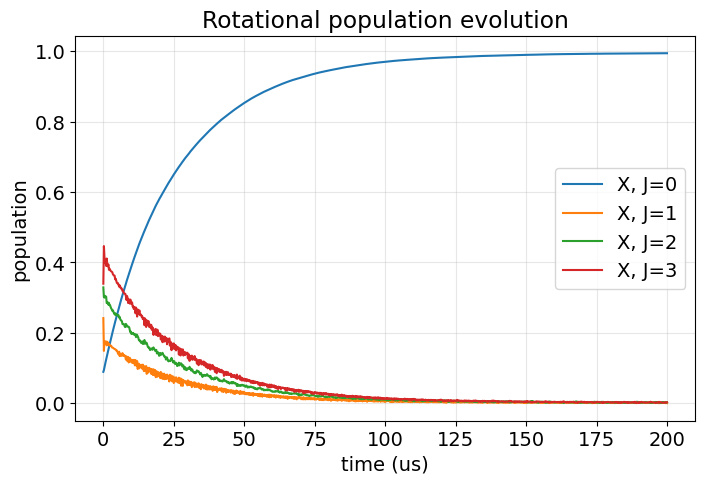

Final rotational population summary
X, J=0: 0.994363
X, J=1: 0.000405
X, J=2: 0.002425
X, J=3: 0.002849
Final X, J=0 target population: 0.994363
{'solver': 'dopri5', 'accepted_steps': 4572, 'rejected_steps': 750, 'rhs_calls': 31933, 'function_evaluations': 31933, 'saved_points': 1001, 'rhs_seconds': 4.517814299790189, 'total_seconds': 4.517814299790189}


In [5]:
baseline = solve_lindblad(
    prepared,
    rho0,
    (0.0, t_final),
    saveat=t_eval,
    output="populations",
    output_when="saveat",
    dense_output=True,
    collect_stats=True,
    **solver_options,
)
baseline_populations = baseline.values
baseline_by_j = populations_by_j(baseline_populations, system)

fig, ax = plt.subplots(figsize=(8, 5))
for j_value, values in baseline_by_j.items():
    ax.plot(1e6 * baseline.t, values, label=f"X, J={j_value}")
ax.set_xlabel("time (us)")
ax.set_ylabel("population")
ax.set_title("Rotational population evolution")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

final_summary = final_populations_by_j(baseline_populations, system)
print("Final rotational population summary")
for j_value, population in final_summary.items():
    print(f"X, J={j_value}: {population:.6f}")
print(
    f"Final X, J=0 target population: {sum(final_summary[j] for j in [0] if j in final_summary):.6f}"
)
print(baseline.solver_stats)

## Pairwise 2D Scans

Each slice scans two parameters from `0.1 Gamma` to `3 Gamma` with `25 x 25` points, holding the other two parameters at their defaults. Lower `scan_points` above for quicker iteration.

In [6]:
scan_results = {}
best_points = []
for pair in scan_pairs:
    print(f"Running slice: {pair[0]} vs {pair[1]}")
    slice_result = run_scan_slice(prepared, rho0, knobs, target_indices, pair)
    scan_results[pair] = slice_result
    best = best_point(slice_result)
    best_points.append(best)
    print(best)

Running slice: Omega_mw_12 vs Omega_mw_23
{'slice': 'Omega_mw_12 vs Omega_mw_23', 'Omega_mw_12': np.float64(1.0666666666666667), 'Omega_mw_23': np.float64(0.42222222222222217), 'X,J=0': np.float64(0.9992196280663034), 'elapsed_s': 113.89435459999368}
Running slice: Omega_mw_12 vs Omega_laser
{'slice': 'Omega_mw_12 vs Omega_laser', 'Omega_mw_12': np.float64(2.3555555555555556), 'Omega_laser': np.float64(3.0), 'X,J=0': np.float64(1.0003243233825323), 'elapsed_s': 77.58380799996667}
Running slice: Omega_mw_12 vs omega_mw_pol
{'slice': 'Omega_mw_12 vs omega_mw_pol', 'Omega_mw_12': np.float64(0.42222222222222217), 'omega_mw_pol': np.float64(0.7444444444444444), 'X,J=0': np.float64(0.9977936310004529), 'elapsed_s': 105.3672720999457}
Running slice: Omega_mw_23 vs Omega_laser
{'slice': 'Omega_mw_23 vs Omega_laser', 'Omega_mw_23': np.float64(1.3888888888888888), 'Omega_laser': np.float64(2.6777777777777776), 'X,J=0': np.float64(1.0003861224622013), 'elapsed_s': 95.45265679992735}
Running slice

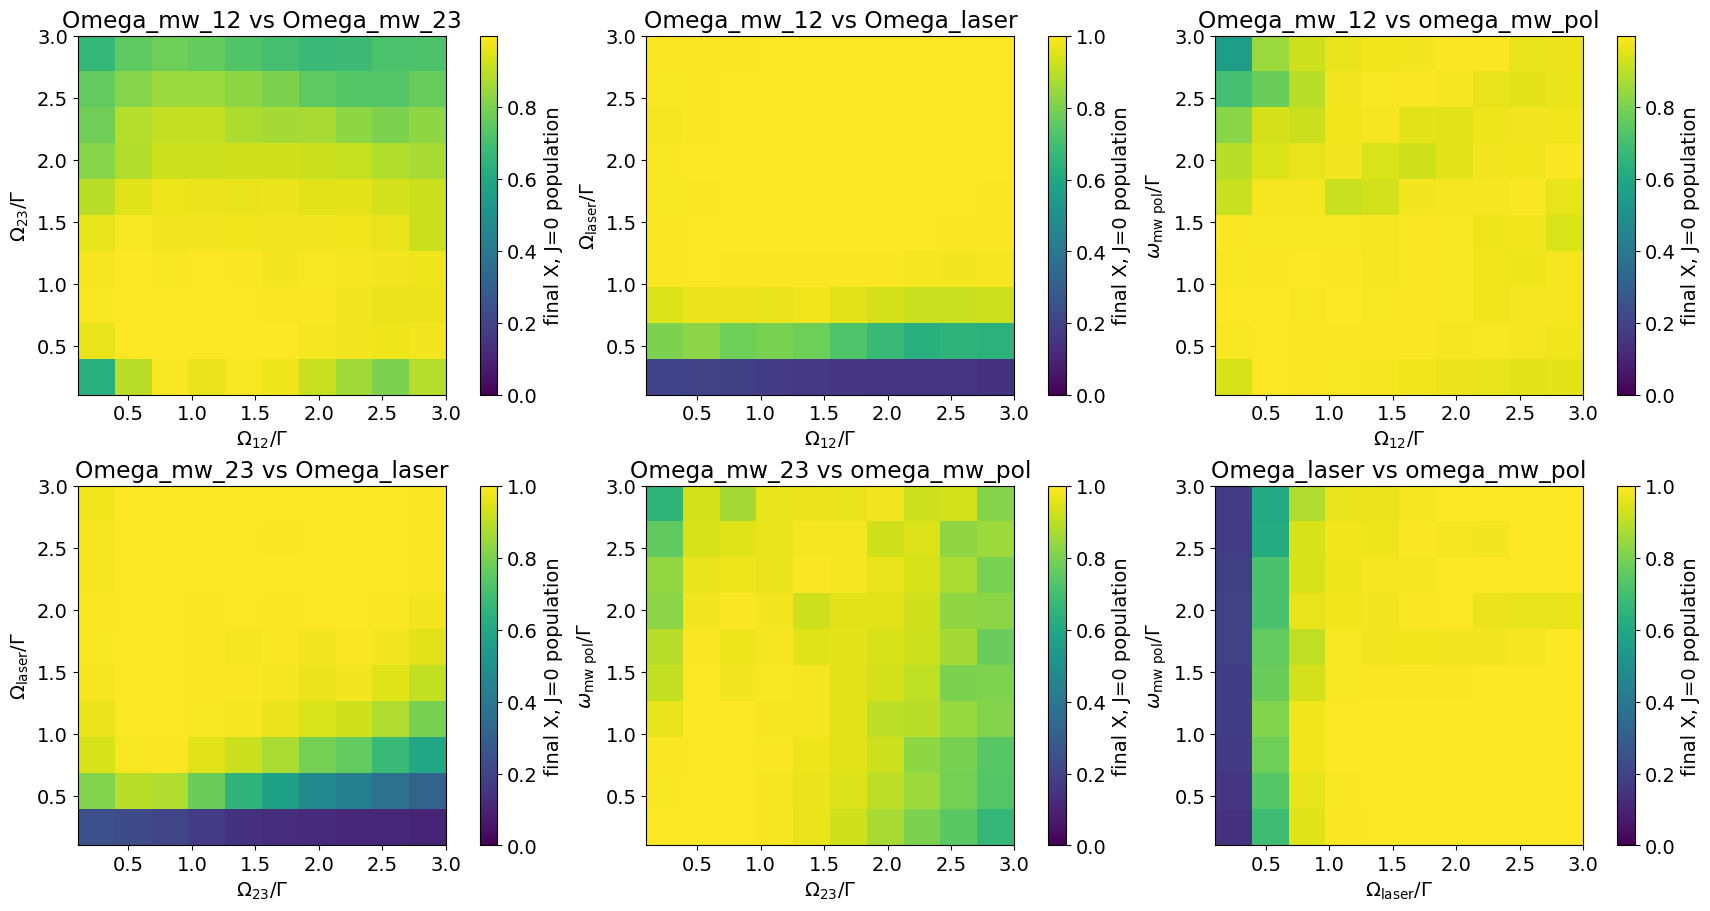

[{'slice': 'Omega_mw_12 vs Omega_mw_23',
  'Omega_mw_12': np.float64(1.0666666666666667),
  'Omega_mw_23': np.float64(0.42222222222222217),
  'X,J=0': np.float64(0.9992196280663034),
  'elapsed_s': 113.89435459999368},
 {'slice': 'Omega_mw_12 vs Omega_laser',
  'Omega_mw_12': np.float64(2.3555555555555556),
  'Omega_laser': np.float64(3.0),
  'X,J=0': np.float64(1.0003243233825323),
  'elapsed_s': 77.58380799996667},
 {'slice': 'Omega_mw_12 vs omega_mw_pol',
  'Omega_mw_12': np.float64(0.42222222222222217),
  'omega_mw_pol': np.float64(0.7444444444444444),
  'X,J=0': np.float64(0.9977936310004529),
  'elapsed_s': 105.3672720999457},
 {'slice': 'Omega_mw_23 vs Omega_laser',
  'Omega_mw_23': np.float64(1.3888888888888888),
  'Omega_laser': np.float64(2.6777777777777776),
  'X,J=0': np.float64(1.0003861224622013),
  'elapsed_s': 95.45265679992735},
 {'slice': 'Omega_mw_23 vs omega_mw_pol',
  'Omega_mw_23': np.float64(0.42222222222222217),
  'omega_mw_pol': np.float64(0.7444444444444444),


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9), constrained_layout=True)
for ax, pair in zip(axes.ravel(), scan_pairs, strict=True):
    result = scan_results[pair]
    axis = result["axis"]
    image = heatmap(
        ax,
        result["grid"],
        axis,
        axis,
        scan_definitions[pair[0]]["label"],
        scan_definitions[pair[1]]["label"],
        f"{pair[0]} vs {pair[1]}",
    )
    fig.colorbar(image, ax=ax, label="final X, J=0 population")
plt.show()

best_points

## Notes

The two microwave drives share `omega_mw_pol`, but the second microwave is phase shifted by `pi / 2`. Because the selectors use complements for the second polarization component, the pair of microwave drives samples four distinct polarization combinations over one microwave switching period.